# Red troncal de Transmilenio - grafo G = (V, E)

Inteligencia Artificial (SIST5036) - Corte 1: Agente inteligente y formulacion.

Este notebook construye el grafo corregido de la red troncal (ver `src/build_graph.py`
para el detalle y la justificacion de cada decision de diseno), muestra la comparacion
antes/despues de corregir la fragmentacion, visualiza la red ya conectada y prueba el
prototipo del agente (`src/agente.py`) con casos que antes eran imposibles.

## 1. Bug corregido y problema de fondo (resumen)

El notebook original de este proyecto (`diagrama_de_red_a_traves_del_dataset`) tenia dos
problemas, verificados al cargar los datos:

1. **Clave de nodo incorrecta**: usaba `nom_est` (el nombre) en `G.add_node()`. El dataset
   tiene un nombre duplicado ("Temporal AV. Jimenez - Inter Electricas" en TZ001 y en TZ015,
   dos estaciones fisicas distintas a ~150 m una de otra), asi que NetworkX fusionaba esas
   dos estaciones en un solo nodo y el segundo `add_node()` sobreescribia los atributos del
   primero. La correccion usa `cod_nodo` (unico en las 153 filas) como clave.
2. **Fragmentacion por id_trazado**: solo se conectaban estaciones consecutivas dentro de
   cada `id_trazado` (17 valores distintos con estaciones), sin conectar nunca las
   transferencias reales ENTRE troncales. Resultado: ~16 componentes desconectadas.

La correccion completa (funciones en `src/build_graph.py`) agrega, en orden:

- (a) conexiones de intercambio (`tipo_esta==3`) entre estaciones cercanas de trazados
  distintos;
- (b) cruces de troncal derivados de puntos compartidos en `ori_traz`/`fin_traz` del
  dataset de Trazados;
- (c) reparacion automatica de troncales fisicas que quedan repartidas en varios
  `id_trazado` (p. ej. Caracas Sur = TZ012+TZ013+TZ014);
- (d) dos conexiones residuales documentadas por proximidad geografica real (Carrera 10
  con Eje Ambiental y con Caracas), para los dos unicos casos sin metadato de cruce
  explicito en el dataset.

El detalle completo de cada umbral y por que se eligio esta en los docstrings de
`src/build_graph.py`.

In [1]:
import sys
sys.path.insert(0, '../src')

import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

from build_graph import (
    cargar_datos,
    construir_grafo_original_con_bug,
    construir_grafo_corregido,
    resumen_componentes,
)

OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

estaciones, trazados = cargar_datos()
print(f"Estaciones cargadas: {len(estaciones)}")
print(f"id_trazado distintos con estaciones: {estaciones['id_trazado'].nunique()}")
print(f"Troncales fisicas (nom_tronc): {trazados['nom_tronc'].nunique()}")

Estaciones cargadas: 153
id_trazado distintos con estaciones: 17
Troncales fisicas (nom_tronc): 13


## 2. Grafo ANTES de la correccion

Se reproduce exactamente la logica original (nombre como clave, solo aristas intra-trazado)
para cuantificar el problema.

In [2]:
G_antes = construir_grafo_original_con_bug(estaciones)
print(f"Nodos: {G_antes.number_of_nodes()} (se esperaban 153 filas; hay menos por el bug de nombre duplicado)")
print(f"Aristas: {G_antes.number_of_edges()}")
print(f"Componentes conexas: {nx.number_connected_components(G_antes)}")

Nodos: 152 (se esperaban 153 filas; hay menos por el bug de nombre duplicado)
Aristas: 136
Componentes conexas: 16


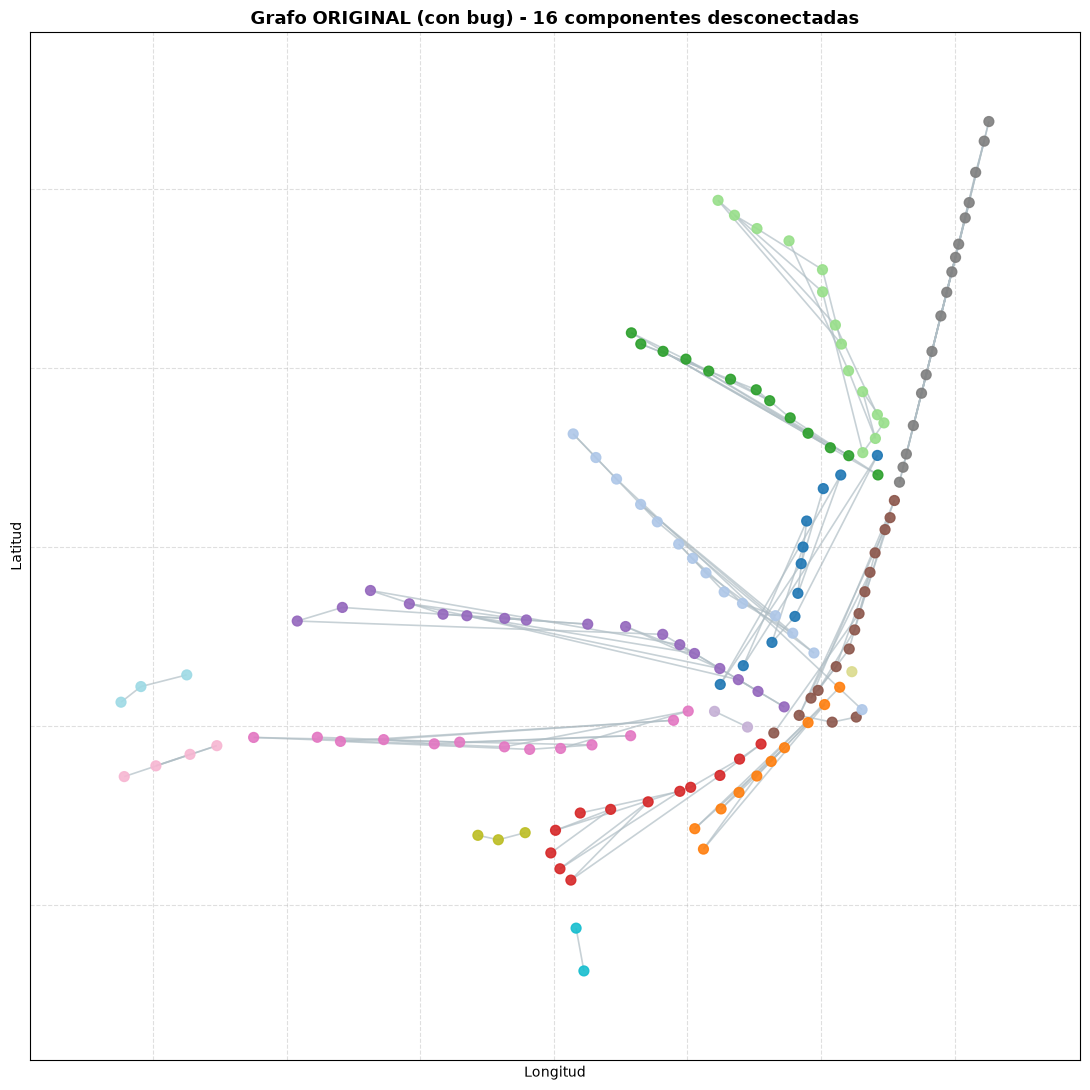

Cada color = una componente conexa distinta (16 componentes = 16 "islas" sin conexion entre si).


In [3]:
comps_antes = list(nx.connected_components(G_antes))
cmap = plt.get_cmap('tab20')
comp_color = {}
for i, c in enumerate(comps_antes):
    for n in c:
        comp_color[n] = cmap(i / max(len(comps_antes) - 1, 1))

pos_antes = nx.get_node_attributes(G_antes, 'pos')
colors_antes = [comp_color[n] for n in G_antes.nodes]

fig, ax = plt.subplots(figsize=(11, 11))
nx.draw_networkx_edges(G_antes, pos_antes, width=1.2, edge_color='#b0bec5', alpha=0.7, ax=ax)
nx.draw_networkx_nodes(G_antes, pos_antes, node_size=50, node_color=colors_antes, alpha=0.9, ax=ax)
ax.set_title(
    f"Grafo ORIGINAL (con bug) - {nx.number_connected_components(G_antes)} componentes desconectadas",
    fontsize=13, fontweight='bold',
)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'red_transmilenio_antes_bug.png', dpi=200)
plt.show()
print('Cada color = una componente conexa distinta (16 componentes = 16 "islas" sin conexion entre si).')

## 3. Grafo DESPUES de la correccion

Se construye con `cod_nodo` como clave y las 4 capas de conexion entre troncales
descritas en la seccion 1 (el log de cada paso, con distancias, se imprime abajo).

In [4]:
G = construir_grafo_corregido(estaciones, trazados)

num_componentes = nx.number_connected_components(G)
print(f"\nnx.number_connected_components(G) = {num_componentes}")
assert num_componentes == 1, "El grafo deberia quedar en 1 sola componente conexa"
print(f"Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}")

1) Aristas intra-trazado: 136 | componentes: 17
2) Aristas de intercambio (tipo_esta==3): 3 | componentes: 14
3) Cruces de troncal (ori_traz/fin_traz compartido):


  aristas de cruce agregadas: 15
  descartados por superar 3.0 km (probable coincidencia de texto, no cruce real):
    TZ009 <-> TZ014: 6.49 km (Ricaurte - CL 13 <-> Biblioteca)
    TZ014 <-> TZ015: 6.76 km (Biblioteca <-> Temporal AV. Jiménez - Inter Eléctricas)
   componentes: 4
4) Reparacion de fragmentacion interna de troncales:
  reparacion interna (Caracas Sur): Santa Lucía <-> Biblioteca (634.8 m)
  reparacion interna (NQS Central): Comuneros <-> Guatoque - Veraguas (547.1 m)
   componentes: 2
5) Conexiones residuales (Carrera 10 / Carrera 7):
  conexion residual: San Victorino <-> Temporal AV. Jimenez (Carrera 10 <-> Eje Ambiental) (291.3 m)
  conexion residual: Las Nieves <-> Calle 19 (Carrera 10 <-> Caracas) (345.8 m)
   componentes: 1

nx.number_connected_components(G) = 1
Nodos: 153 | Aristas: 158


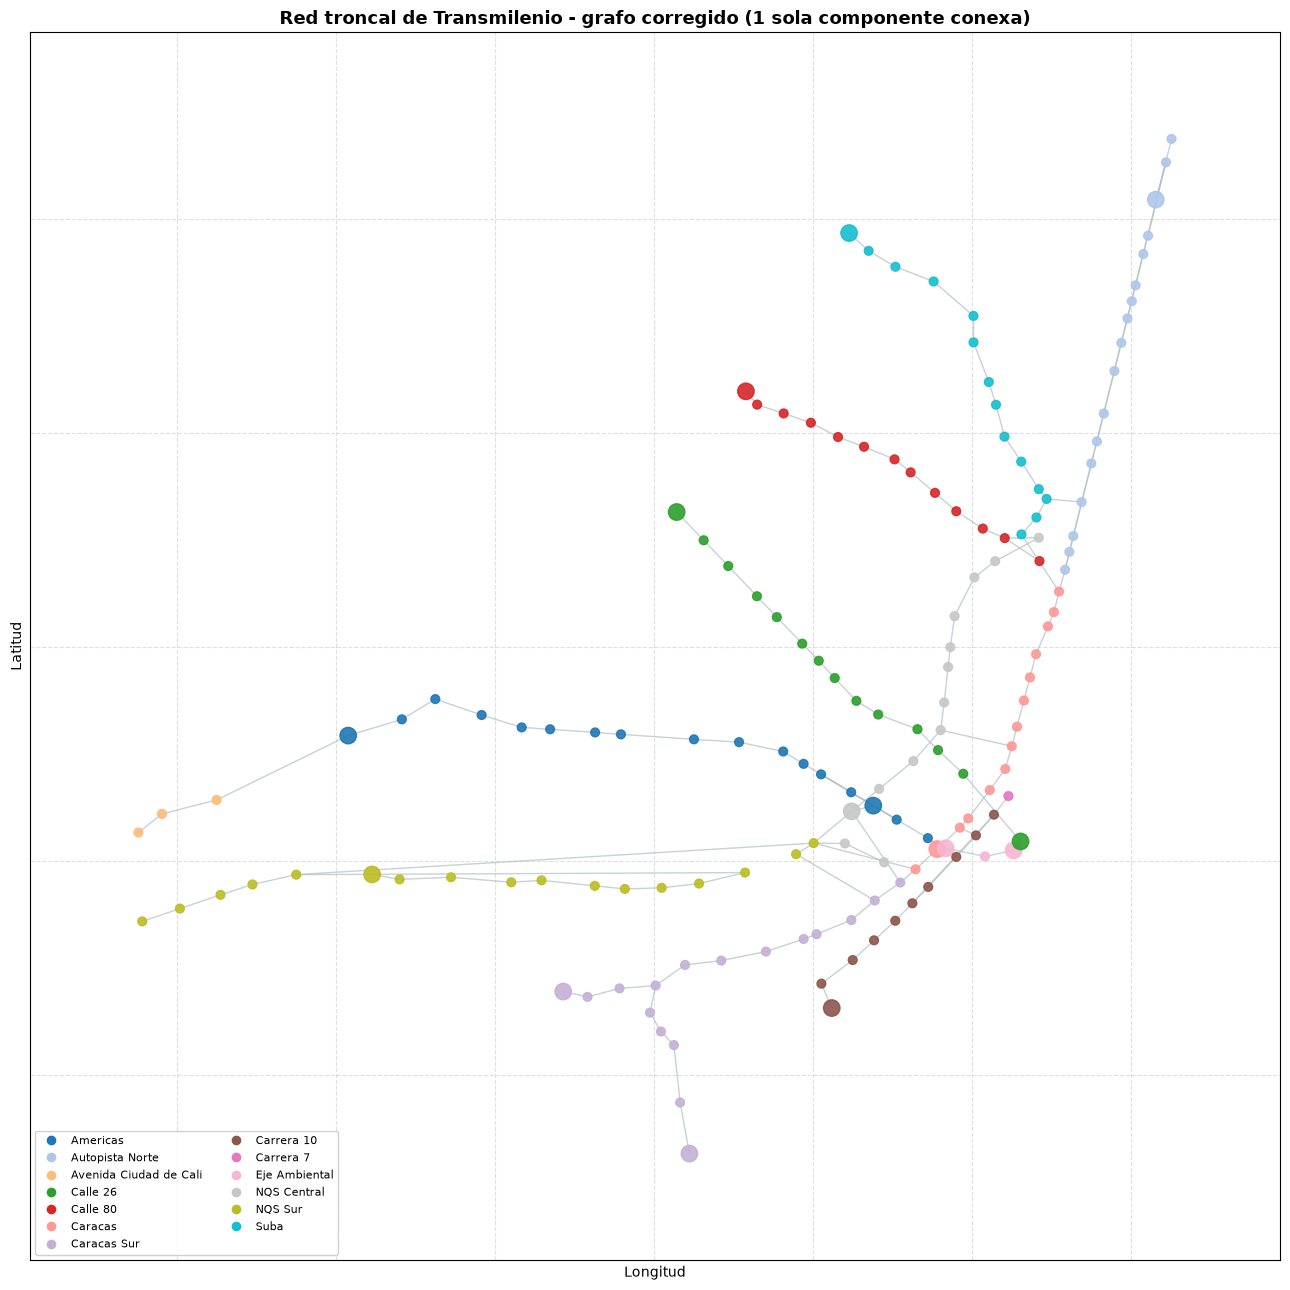

In [5]:
troncales = sorted({d['nom_tronc'] for _, d in G.nodes(data=True)})
cmap = plt.get_cmap('tab20')
color_map = {t: cmap(i / len(troncales)) for i, t in enumerate(troncales)}
colors = [color_map[G.nodes[n]['nom_tronc']] for n in G.nodes]
pos = {n: (G.nodes[n]['lon'], G.nodes[n]['lat']) for n in G.nodes}
# Portales e intercambios se dibujan mas grandes para resaltar los puntos clave de la red
sizes = [140 if G.nodes[n]['tipo_esta'] in (1, 3) else 40 for n in G.nodes]

fig, ax = plt.subplots(figsize=(13, 13))
nx.draw_networkx_edges(G, pos, width=1.0, edge_color='#b0bec5', alpha=0.7, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, alpha=0.9, ax=ax)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[t], markersize=8, label=t)
    for t in troncales
]
ax.legend(handles=handles, loc='lower left', fontsize=8, ncol=2, framealpha=0.9)
ax.set_title('Red troncal de Transmilenio - grafo corregido (1 sola componente conexa)', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'red_transmilenio_corregida.png', dpi=200)
plt.show()

## 4. Estadisticas del grafo corregido

In [6]:
with open(OUTPUT_DIR / 'estadisticas_grafo.json', encoding='utf-8') as f:
    stats = json.load(f)
print(json.dumps(stats, ensure_ascii=False, indent=2))

{
  "num_nodos": 153,
  "num_aristas": 158,
  "num_componentes_conexas": 1,
  "num_troncales_fisicas": 13,
  "num_trazados": 22,
  "troncales_fisicas": [
    "Americas",
    "Autopista Norte",
    "Avenida Ciudad de Cali",
    "Calle 26",
    "Calle 80",
    "Caracas",
    "Caracas Sur",
    "Carrera 10",
    "Carrera 7",
    "Eje Ambiental",
    "NQS Central",
    "NQS Sur",
    "Suba"
  ],
  "estaciones_por_tipo": {
    "Sencilla": 129,
    "Intermedia": 9,
    "Intercambio": 6,
    "Portal": 9
  },
  "grado_promedio": 2.065,
  "grado_maximo": 5,
  "estacion_grado_maximo": "Comuneros",
  "densidad": 0.01359
}


## 5. Prototipo del agente: rutas antes imposibles

Se prueban pares origen-destino que, en el grafo original fragmentado, estaban en
componentes distintas y por lo tanto `nx.shortest_path` habria lanzado `NetworkXNoPath`.

In [7]:
from agente import AgenteRutas

agente = AgenteRutas(G)
_ = agente.imprimir_ruta(3000, 8000)  # Portal Suba -> Portal Tunal

Ruta: Portal Suba -> Portal Tunal
  Estaciones: 40 | Transferencias: 2 | Costo total: 25.769 km | Tiempo de calculo: 3.859 ms | Memoria pico: 49.29 KB
   1. Portal Suba (Suba)
   2. La Campiña (Suba)
   3. Suba - TV. 91 (Suba)
   4. 21 Ángeles (Suba)
   5. Gratamira (Suba)
   6. Suba - AV. Boyacá (Suba)
   7. Niza - Calle 127 (Suba)
   8. Humedal Córdoba (Suba)
   9. Suba - Calle 116 (Suba)
  10. Puentelargo (Suba)
  11. Suba - Calle 100 (Suba)
  12. Suba - Calle 95 (Suba)
  13. Rionegro (Suba)
  14. San Martín (Suba)
  15. Calle 76 - San Felipe (Caracas) <-- transferencia
  16. Calle 72 - Areandina (Caracas)
  17. Temporal Flores – Areandina (Caracas)
  18. Calle 63 (Caracas)
  19. Temporal Calle 57 (Caracas)
  20. Temporal Marly (Caracas)
  21. Calle 45 - American School Way (Caracas)
  22. Temporal AV. 39 (Caracas)
  23. Temporal Calle 34 (Caracas)
  24. Calle 26 - Atrio (Caracas)
  25. Temporal Calle 22 (Caracas)
  26. Calle 19 (Caracas)
  27. Temporal AV. Jiménez - Inter Eléctrica

In [8]:
_ = agente.imprimir_ruta(10009, 5000)  # Museo Nacional (Carrera 7) -> Portal Americas

Ruta: Museo Nacional -> Portal Américas
  Estaciones: 22 | Transferencias: 5 | Costo total: 15.93 km | Tiempo de calculo: 1.271 ms | Memoria pico: 7.91 KB
   1. Museo Nacional (Carrera 7)
   2. San Diego (Carrera 10) <-- transferencia
   3. Las Nieves (Carrera 10)
   4. Calle 19 (Caracas) <-- transferencia
   5. Temporal AV. Jiménez - Inter Eléctricas (Caracas)
   6. Tercer Milenio (Caracas)
   7. Hospital (Caracas Sur) <-- transferencia
   8. Ricaurte - NQS (NQS Central) <-- transferencia
   9. Ricaurte - CL 13 (Americas) <-- transferencia
  10. CDS - Carrera 32 (Americas)
  11. Carrera 43 - Comapan (Americas)
  12. Puente Aranda (Americas)
  13. Distrito Grafiti (Americas)
  14. Pradera - Plaza Central (Americas)
  15. Marsella (Americas)
  16. AV. Américas - AV. Boyacá (Americas)
  17. Mandalay (Americas)
  18. Banderas (Americas)
  19. Transversal 86 (Americas)
  20. Biblioteca Tintal (Americas)
  21. Patio Bonito (Americas)
  22. Portal Américas (Americas)


Ver `src/pruebas_agente.py` para el set completo de 3 pruebas y `outputs/pruebas_agente.json`
para los resultados guardados.

## 6. Rendimiento del agente y visualizacion de una ruta resaltada

Se mide el tiempo de calculo y la memoria pico de `AgenteRutas.calcular_ruta()` (ver `src/agente.py`) para los 3 casos de prueba, y se dibuja una de las rutas resaltada sobre la red completa con `src/visualizar_ruta.py`.

In [9]:
from visualizar_ruta import CASOS, dibujar_ruta
import pandas as pd

filas = []
for caso in CASOS:
    r = agente.calcular_ruta(caso["origen"], caso["destino"])
    filas.append({
        "ruta": f"{r['origen']} -> {r['destino']}",
        "tiempo_calculo_ms": round(r["tiempo_calculo_ms"], 3),
        "memoria_pico_kb": round(r["memoria_pico_kb"], 2),
        "num_estaciones": r["num_estaciones"],
        "num_transferencias": r["num_transferencias"],
    })

pd.DataFrame(filas)

,ruta,tiempo_calculo_ms,memoria_pico_kb,num_estaciones,num_transferencias
0,Portal Suba -> Portal Tunal,2.062,13.06,40,2
1,Portal Norte – Unicervantes -> Portal Usme,1.944,11.37,44,2
2,Museo Nacional -> Portal Américas,0.691,7.91,22,5


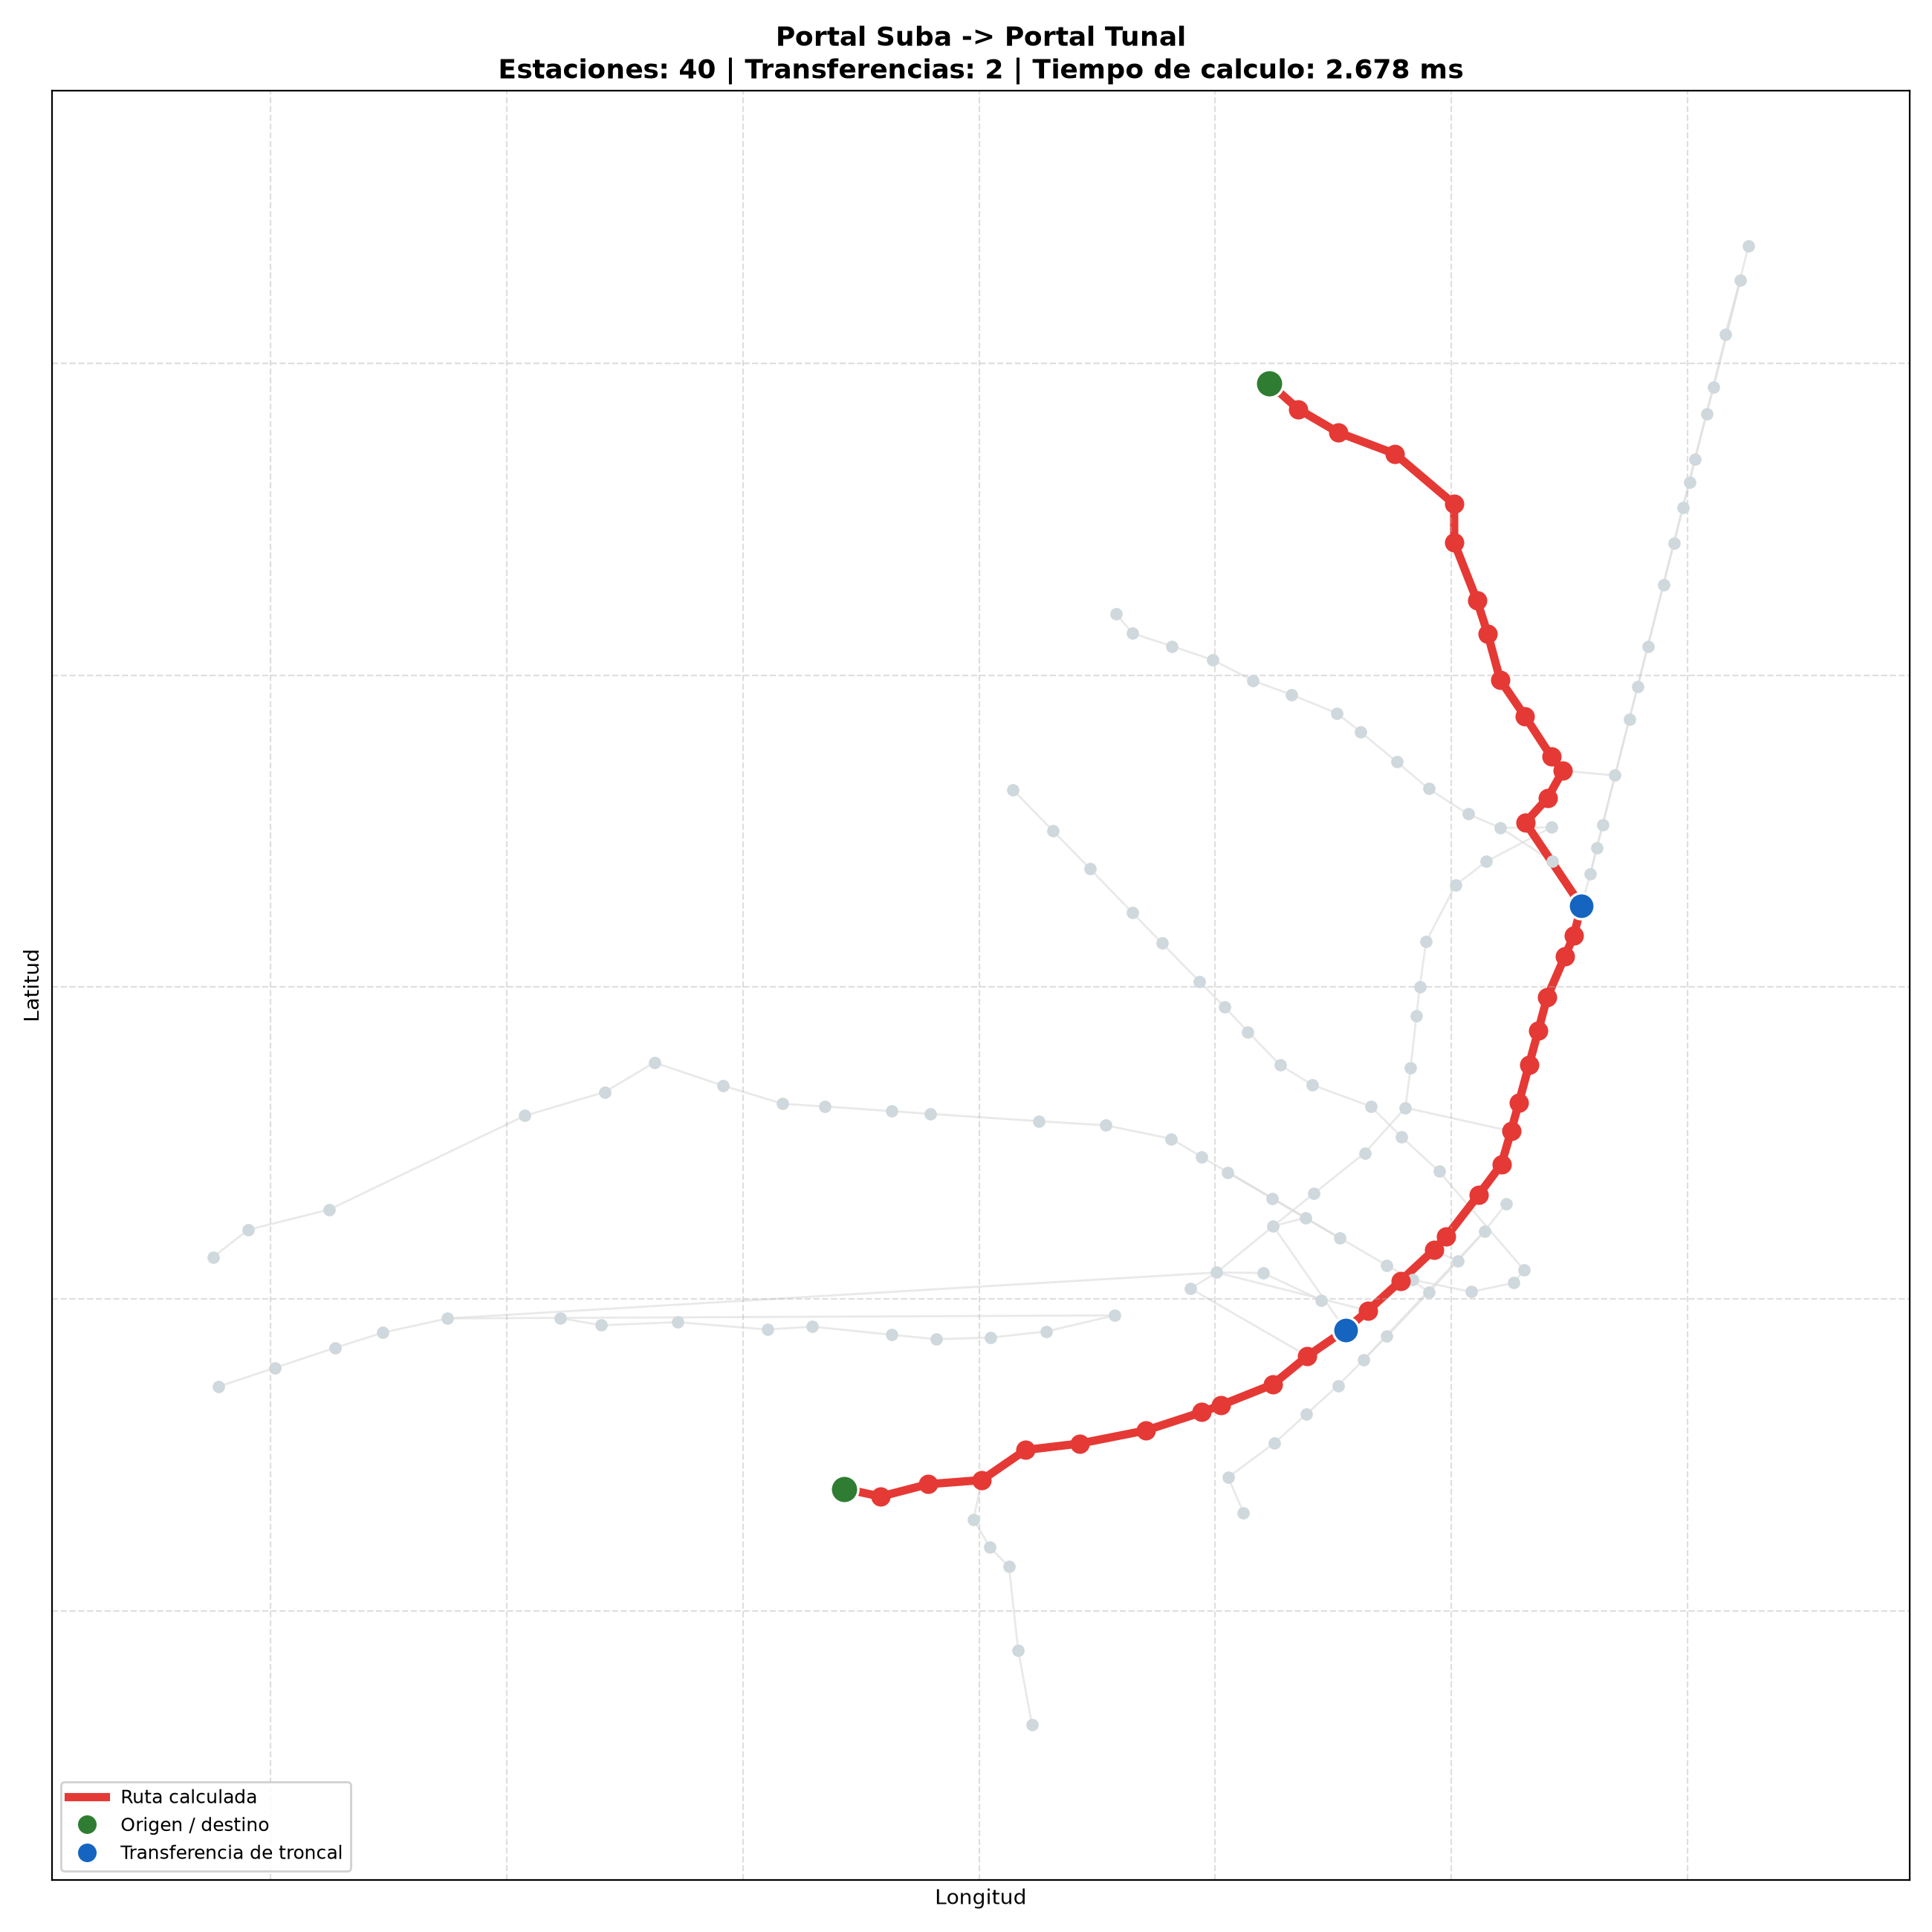

In [10]:
from IPython.display import Image, display

caso_demo = CASOS[0]  # Portal Suba -> Portal Tunal
archivo_demo = OUTPUT_DIR / caso_demo["archivo"]
dibujar_ruta(agente, caso_demo["origen"], caso_demo["destino"], archivo_demo)
display(Image(filename=str(archivo_demo)))